In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import normalize

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [3]:
df=pd.read_csv(r"C:\Users\Sabahat Parween\Downloads\Tata-steel.csv")

In [4]:
print(df.head())

        Date  Open Price  High Price  Low Price  Close Price         WAP  \
0  03-Jul-15      308.00      308.00     299.75       300.95  302.708180   
1  06-Jul-15      294.90      299.60     292.30       298.75  295.646338   
2  07-Jul-15      300.75      303.25     296.00       297.45  299.477691   
3  08-Jul-15      293.80      294.00     282.00       283.40  286.875105   
4  09-Jul-15      285.20      287.25     279.60       280.55  282.860975   

   No.of Shares  No. of Trades  Total Turnover (Rs.)  Deliverable Quantity  \
0        499554           6430             151219082              118810.0   
1        663354           9184             196118181              117663.0   
2        877207           8581             262703927              211277.0   
3       1446189          20272             414875621              563505.0   
4        974983          13946             275784642              330248.0   

   % Deli. Qty to Traded Qty  Spread High-Low  Spread Close-Open  
0      

In [7]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

C:\Users\Sabahat Parween\AppData\Local\Temp\ipykernel_13472\171143142.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [8]:
numeric_df=df.iloc[:,2:-1]
print(df.isnull().sum())
print(df.isnull().values.any())
print(df.dtypes)
for col in df.columns:
    if col != "Date":
        df[col] = pd.to_numeric(df[col], errors="coerce")

Date                         0
Open Price                   0
High Price                   0
Low Price                    0
Close Price                  0
WAP                          0
No.of Shares                 0
No. of Trades                0
Total Turnover (Rs.)         0
Deliverable Quantity         1
% Deli. Qty to Traded Qty    1
Spread High-Low              0
Spread Close-Open            0
dtype: int64
True
Date                         datetime64[us]
Open Price                          float64
High Price                          float64
Low Price                           float64
Close Price                         float64
WAP                                 float64
No.of Shares                          int64
No. of Trades                         int64
Total Turnover (Rs.)                  int64
Deliverable Quantity                float64
% Deli. Qty to Traded Qty           float64
Spread High-Low                     float64
Spread Close-Open                   float64
dtype: 

In [12]:
df = df.interpolate(method="linear")
df = df.ffill().bfill()
data = df[["Close Price"]]


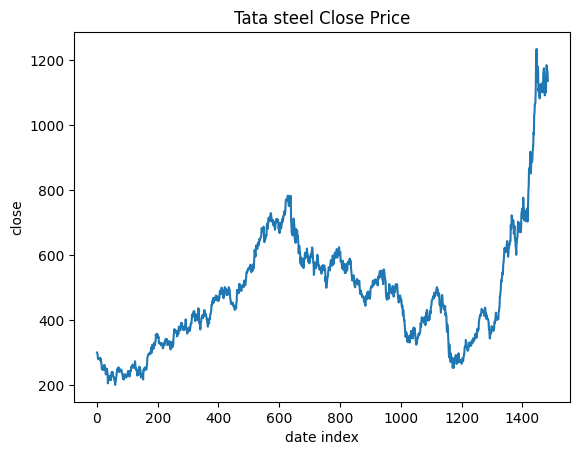

In [13]:
plt.plot(data)
plt.title("Tata steel Close Price")
plt.xlabel("date index")
plt.ylabel("close")
plt.show()

In [14]:

data = data.values.astype(np.float32)

In [15]:
TRAIN_RATIO=0.8
INPUT_STEPS=10
OUTPUT_STEPS=1

In [16]:
split_idx = int(len(data) * TRAIN_RATIO)

train_data1 = data[:split_idx]
test_data = data[split_idx:]

val_split_idx = int(len(train_data1) * 0.8)

train_data = train_data1[:val_split_idx]
val_data = train_data1[val_split_idx:]

In [17]:
train_data.shape,test_data.shape,val_data.shape

((950, 1), (297, 1), (238, 1))

In [18]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

train_data = scaler.fit_transform(train_data)
val_data = scaler.transform(val_data)
test_data = scaler.transform(test_data)

In [19]:
def create_sequences(data,INPUT_STEPS,OUTPUT_STEPS):
    X, y = [], []


    for i in range(len(data)-INPUT_STEPS - OUTPUT_STEPS):
        X.append(data[i:i+INPUT_STEPS])
        y.append(data[i+INPUT_STEPS:i+INPUT_STEPS+OUTPUT_STEPS])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data,INPUT_STEPS,OUTPUT_STEPS)
X_val, y_val = create_sequences(val_data,INPUT_STEPS,OUTPUT_STEPS)
X_test, y_test = create_sequences(test_data,INPUT_STEPS,OUTPUT_STEPS)

In [20]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [21]:
train_loader = DataLoader(TimeSeriesDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(X_val, y_val), batch_size=32,shuffle=False)
test_loader = DataLoader(TimeSeriesDataset(X_test, y_test), batch_size=32,shuffle=False)

In [22]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=100, batch_first=True)
        self.fc = nn.Linear( 100,1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out.unsqueeze(-1)

In [23]:
model = LSTMModel()

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [25]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

In [26]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)

            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

In [27]:
EPOCHS = 30
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

Epoch [1/30] | Train Loss: 0.086352 | Val Loss: 0.013818
Epoch [2/30] | Train Loss: 0.016360 | Val Loss: 0.002440
Epoch [3/30] | Train Loss: 0.004629 | Val Loss: 0.002242
Epoch [4/30] | Train Loss: 0.002085 | Val Loss: 0.001582
Epoch [5/30] | Train Loss: 0.001204 | Val Loss: 0.001498
Epoch [6/30] | Train Loss: 0.000966 | Val Loss: 0.001560
Epoch [7/30] | Train Loss: 0.000992 | Val Loss: 0.001483
Epoch [8/30] | Train Loss: 0.001006 | Val Loss: 0.001488
Epoch [9/30] | Train Loss: 0.000928 | Val Loss: 0.001532
Epoch [10/30] | Train Loss: 0.000988 | Val Loss: 0.001573
Epoch [11/30] | Train Loss: 0.000914 | Val Loss: 0.001969
Epoch [12/30] | Train Loss: 0.001046 | Val Loss: 0.002196
Epoch [13/30] | Train Loss: 0.000948 | Val Loss: 0.001444
Epoch [14/30] | Train Loss: 0.000938 | Val Loss: 0.001425
Epoch [15/30] | Train Loss: 0.000918 | Val Loss: 0.001430
Epoch [16/30] | Train Loss: 0.000893 | Val Loss: 0.001470
Epoch [17/30] | Train Loss: 0.000873 | Val Loss: 0.001340
Epoch [18/30] | Train L

In [28]:
EPOCHS = 6
PATIENCE = 5   

train_losses = []
val_losses = []

best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

    
        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch [1/6] | Train Loss: 0.001109 | Val Loss: 0.001111
Epoch [2/6] | Train Loss: 0.000839 | Val Loss: 0.001150
Epoch [3/6] | Train Loss: 0.000728 | Val Loss: 0.001142
Epoch [4/6] | Train Loss: 0.000718 | Val Loss: 0.001169
Epoch [5/6] | Train Loss: 0.000719 | Val Loss: 0.001041
Epoch [6/6] | Train Loss: 0.000759 | Val Loss: 0.001058


In [29]:
test_loss, predictions, targets = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.6f}")

Test Loss: 0.005202


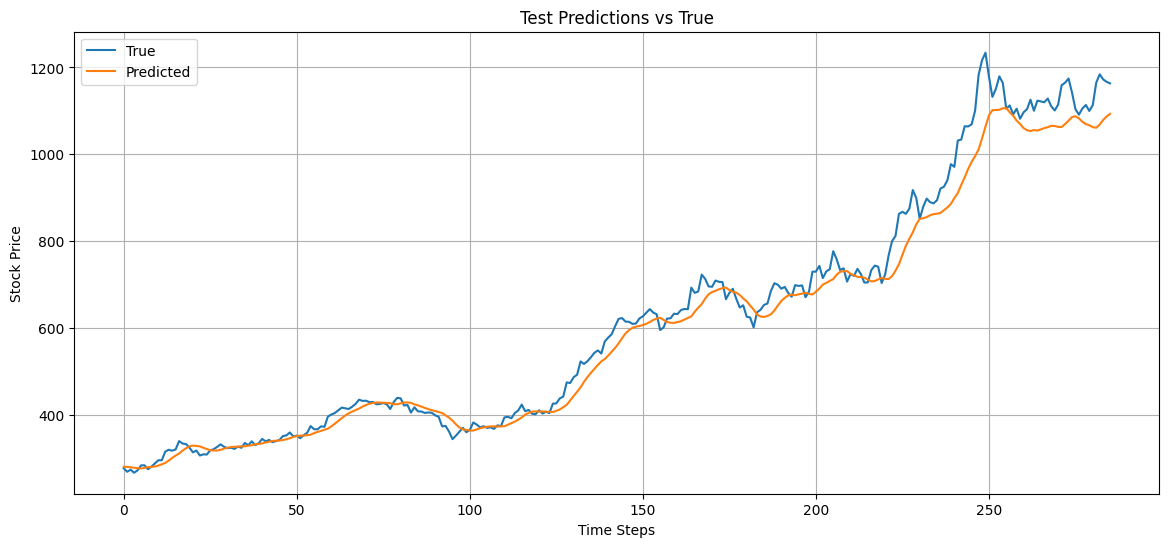

In [30]:
predictions_reshaped = predictions.reshape(-1, 1)
targets_reshaped = targets.reshape(-1, 1)

predictions_inv = scaler.inverse_transform(predictions_reshaped)
targets_inv = scaler.inverse_transform(targets_reshaped)

plt.figure(figsize=(14, 6))
plt.plot(targets_inv, label="True")
plt.plot(predictions_inv, label="Predicted")

plt.title("Test Predictions vs True")
plt.xlabel("Time Steps")
plt.ylabel("Stock Price")

plt.legend()
plt.grid(True)
plt.show()